<a href="https://colab.research.google.com/github/Thamizhselvan-229/Deep-Learning/blob/main/DL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 170M/170M [03:14<00:00, 875kB/s]


Epoch 1: Loss = 1.7011, Accuracy = 39.80%
Epoch 2: Loss = 1.4838, Accuracy = 48.31%
Epoch 3: Loss = 1.3890, Accuracy = 51.65%
Epoch 4: Loss = 1.3158, Accuracy = 54.15%
Epoch 5: Loss = 1.2595, Accuracy = 56.23%
Epoch 6: Loss = 1.2094, Accuracy = 57.92%
Epoch 7: Loss = 1.1635, Accuracy = 59.64%
Epoch 8: Loss = 1.1220, Accuracy = 61.07%
Epoch 9: Loss = 1.0771, Accuracy = 62.68%
Epoch 10: Loss = 1.0432, Accuracy = 63.70%
Epoch 1: Loss = 1.6451, Accuracy = 42.29%
Epoch 2: Loss = 1.4402, Accuracy = 49.44%
Epoch 3: Loss = 1.3525, Accuracy = 52.96%
Epoch 4: Loss = 1.2815, Accuracy = 55.47%
Epoch 5: Loss = 1.2163, Accuracy = 57.72%
Epoch 6: Loss = 1.1634, Accuracy = 59.55%
Epoch 7: Loss = 1.1139, Accuracy = 61.50%
Epoch 8: Loss = 1.0635, Accuracy = 63.14%
Epoch 9: Loss = 1.0232, Accuracy = 64.57%
Epoch 10: Loss = 0.9767, Accuracy = 66.08%


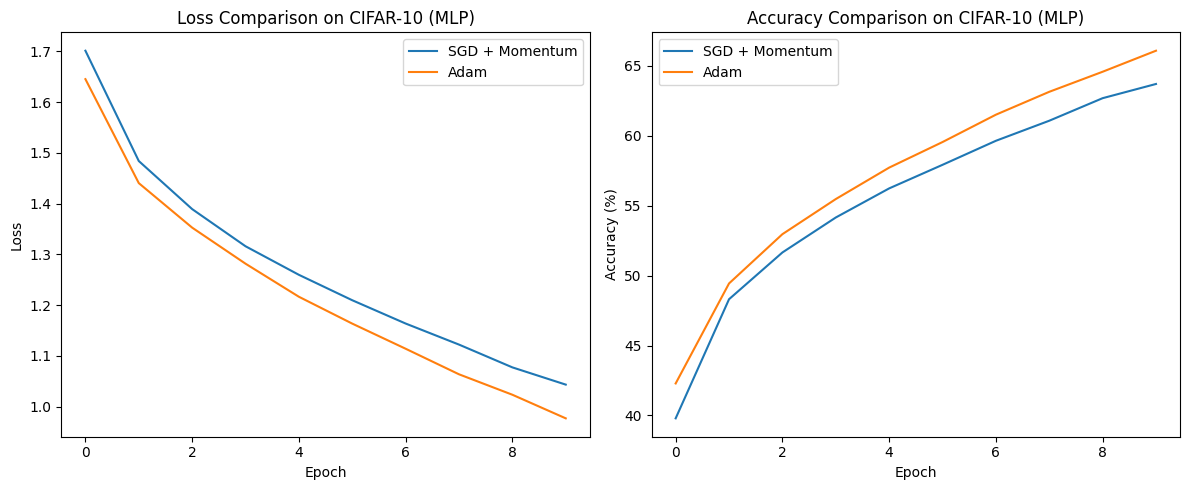

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True
)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(3 * 32 * 32, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

def train(model, optimizer, epochs=10):
    model.to(device)

    loss_fn = nn.CrossEntropyLoss()
    losses = []
    accuracies = []

    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        model.train()

        for imgs, labels in trainloader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_loss = total_loss / len(trainloader)
        accuracy = 100.0 * correct / total

        losses.append(avg_loss)
        accuracies.append(accuracy)

        print(
            f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, "
            f"Accuracy = {accuracy:.2f}%"
        )

    return losses, accuracies

model_sgd = MLP()
sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9
)

losses_sgd, acc_sgd = train(model_sgd, sgd)

model_adam = MLP()
adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001
)

losses_adam, acc_adam = train(model_adam, adam)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses_sgd, label="SGD + Momentum")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison on CIFAR-10 (MLP)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_sgd, label="SGD + Momentum")
plt.plot(acc_adam, label="Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison on CIFAR-10 (MLP)")
plt.legend()

plt.tight_layout()
plt.show()